# Two Research Groups Fitting the Same Outbreak### A diagnostic vignette: why the same data yields different $\mathcal{R}_0$ estimates**Companion text:** Hyman, J. M., Qu, Z., & Xue, L. (2026). *Essential Considerations for Modeling Epidemics: A Modern Introduction to Theory, Data, and Computation*. Manuscript in preparation.**Sections covered:** Chapter 1, §1.1 ("Why This Book Exists"), the two-research-groups vignette**Equations implemented:** $\hat\lambda = J/S^*$ and $\hat\alpha = J/I$ (the susceptible- vs infected-viewpoint estimators)**Theorems / results verified:** Structural-immunity property of $\hat\alpha$ — zero sensitivity to assumed susceptible fraction (verified numerically across a parametric sweep)**Figures reproduced:** Figure 1.1 (the two estimates plotted side-by-side with the true $\mathcal{R}_0$)**Considerations developed:** 4 (force *of* vs force *from* infection), 8 (correct data-fitting practice), 9 (identifiability), 12 ($\mathcal{R}_0$ vs $\mathcal{R}_e(t)$)**Learning objectives:**- See the book's central methodological argument compressed into a single example- Implement both viewpoint estimators and observe their disagreement under a misspecified $S^*$- Verify numerically that $\hat\alpha$ inherits zero sensitivity to assumed susceptible fraction (Consideration 4)- Recognize when an estimate of "$\mathcal{R}_0$" is actually estimating $\mathcal{R}_e(t)$ (Consideration 12)**Prerequisites:** Familiarity with the SIR model and basic Python. No prior exposure to fitting needed.**Context:**- This is the *first* notebook in the companion repository; it sets up the methodological frame for everything that follows.- Next notebook: `chapter_02_infection_equation/01_compartments_and_contact_rates.ipynb` — formalizes the contact rates the vignette uses informally.- The full rigorous treatment of the disagreement is in Chapter 8; this notebook plants the seed.[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/machyman/hyman2026essential/blob/main/python/notebooks/chapter_01_introduction/01_two_research_groups.ipynb)**Estimated runtime:** < 1 min on Colab free tier (QUICK mode); < 3 min (FULL mode).

## Setup

In [1]:
# === Module-level docstring ===
"""
Two Research Groups Fitting the Same Outbreak
=============================================
Reproduces the opening vignette of Chapter 1, §1.1 in the companion text:
two research groups fit the same epidemic data and reach different
estimates of the basic reproductive number. The disagreement is traced
to a single methodological choice — which viewpoint (susceptible or
infected) anchors the estimator — and the structural-immunity property
of the infected-viewpoint estimator $\hat\alpha$ is verified numerically.

Companion text
--------------
Hyman, J. M., Qu, Z., & Xue, L. (2026). Essential Considerations for
Modeling Epidemics: A Modern Introduction to Theory, Data, and
Computation. Manuscript in preparation.

Sections, equations, and considerations
---------------------------------------
§1.1               -> the two-research-groups vignette this notebook implements
Eq. (lambda_hat)   -> susceptible-viewpoint estimator J/S*
Eq. (alpha_hat)    -> infected-viewpoint estimator J/I
Consideration 4    -> force of vs force from infection
Consideration 8    -> correct data-fitting practice
Consideration 12   -> R_0 (basic) vs R_e(t) (effective)

Author
------
James M. Hyman, Department of Mathematics, Tulane University
mhyman@tulane.edu
2026-05-01  Version 2.0  (v2.0 skill upgrade — exemplar for co-author review)
"""

# === Standard imports ===
import sys, os, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings('ignore')

# Add the python/ directory to sys.path so we can import shared/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from shared import (
    set_seed_chapter_01,
    book_style,
    BOOK_COLORS,
    integrate_sir_i,
)
from shared.parameters import baseline_chapter_07
from shared.verification import assert_within_tolerance

# === Reproducibility ===
SEED = 42                                  # global seed for any non-chapter-specific randomness
RNG  = np.random.default_rng(SEED)         # preferred over np.random.seed (NumPy >= 1.17)
np.random.seed(SEED)                       # for legacy code paths
set_seed_chapter_01()                      # chapter-specific seed (shared/seeds.py convention)

# === Plot style (book-consistent figure conventions from shared/plotting.py) ===
book_style()

# === Scale switch: QUICK for verification, FULL for publication-quality output ===
# QUICK runs in well under 1 minute on a CPU; FULL adds a finer parametric sweep.
FULL = False

SCALE = dict(
    n_sweep_fractions = 12 if FULL else 6,    # number of susceptible-fraction sweep points
    noise_sigma_frac  = 0.05,                  # noise std as fraction of peak incidence
)
print(f"Scale: {'FULL (publication)' if FULL else 'QUICK (verification)'}")
print(f"Parameters: {SCALE}")


<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:2: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_160/462677732.py:2: SyntaxWarning: invalid escape sequence '\h'
  """


Scale: QUICK (verification)
Parameters: {'n_sweep_fractions': 6, 'noise_sigma_frac': 0.05}


## Background and the question  (§1.1)In the companion text's opening vignette, two research groups receive identical incidence data $J(t)$ from a moderate-sized outbreak. Both fit it to estimate the basic reproductive number $\mathcal{R}_0$. They reach different answers. *Why?*The disagreement is not a bug. It is a structural consequence of which **viewpoint** each group anchors its estimator on:- **Group A (susceptible viewpoint)** estimates the *force of infection* acting on susceptibles:  $$\hat\lambda \;=\; \frac{J}{S^*}\,,$ (Eq. 1.1)$  where $S^*$ is the *assumed* susceptible population. To convert $\hat\lambda$ to $\mathcal{R}_0$, Group A must commit to a value of $S^*$. They assume $S^* = N$ (the entire population is susceptible at outbreak start).- **Group B (infected viewpoint)** estimates the *force from infection* emitted by infectious individuals:  $$\hat\alpha \;=\; \frac{J}{I}\,.$$  Group B uses the *observed* infectious population $I(t)$ and never invokes an assumption about $S^*$.> **The book's claim** (Chapter 1, §1.1; Consideration 4): *whose perspective the model takes determines what is invariant under the data.* When $S^*$ is misspecified, $\hat\lambda$ inherits the error and $\hat\alpha$ does not. We verify this property numerically below.> **Departure from text:** The companion text introduces the vignette qualitatively. This notebook makes it quantitative with synthetic data generated from a known SIR_I ground truth, so that the "right answer" is available for comparison. The synthetic-data choice trades realism for transparency; real-outbreak fits appear from Chapter 8 onward.

## Verification SuiteBefore the main computation, verify the two estimators against a hand-computed sanity case (Consideration 8: verify the formula before trusting it).

In [2]:
# === Verification Suite ============================================
# Pre-computation sanity checks for the two estimators.
# Each test: one assertion + one print('Test N PASS: ...').
# Failure halts the notebook before wasting compute.
print("=" * 65)
print("VERIFICATION SUITE")
print("=" * 65)

# --- Test 1: alpha-hat sanity check (Eq: alpha_hat = J/I) -----------
# Hand-computed: if J = 0.01 (1% of N per day) and I = 0.005 (0.5% of N),
# then alpha_hat = 2.0 day^-1.
J_test, I_test = 0.01, 0.005
alpha_hat_test = J_test / I_test
assert abs(alpha_hat_test - 2.0) < 1e-12, "FAIL: alpha_hat formula"
print(f"Test 1 PASS  alpha_hat = {alpha_hat_test:.4f} day^-1  (J/I sanity, Consideration 4)")

# --- Test 2: lambda-hat sanity check (Eq: lambda_hat = J/S*) --------
# Same J = 0.01; if S* = 1.0 (full population), then lambda_hat = 0.01.
S_star_test = 1.0
lambda_hat_test = J_test / S_star_test
assert abs(lambda_hat_test - 0.01) < 1e-12, "FAIL: lambda_hat formula"
print(f"Test 2 PASS  lambda_hat = {lambda_hat_test:.4f} day^-1  (J/S* sanity, Consideration 4)")

# --- Test 3: structural relation (Eq: lambda*S = alpha*I = J) -------
# At any time, the incidence equality lambda*S = alpha*I = J must hold
# (this is the algebraic identity Group A and Group B both implicitly use).
S_test = 1.0
assert abs(lambda_hat_test * S_test - alpha_hat_test * I_test) < 1e-12, \
    "FAIL: incidence identity lambda*S = alpha*I violated"
print(f"Test 3 PASS  lambda*S = alpha*I = {lambda_hat_test * S_test:.4f}  (incidence identity)")

# --- Test 4: SIR_I integrator returns expected keys -----------------
params_test = baseline_chapter_07()
result_test = integrate_sir_i(params_test)
required_keys = {'t', 'S', 'I', 'R'}
assert required_keys.issubset(result_test.keys()), \
    f"FAIL: integrate_sir_i missing keys {required_keys - set(result_test.keys())}"
print(f"Test 4 PASS  integrate_sir_i returns {sorted(required_keys)}  (shared/solvers.py contract)")

N_TESTS = 4
print(f"\nAll {N_TESTS} verification tests PASSED.")
print("=" * 65)


VERIFICATION SUITE
Test 1 PASS  alpha_hat = 2.0000 day^-1  (J/I sanity, Consideration 4)
Test 2 PASS  lambda_hat = 0.0100 day^-1  (J/S* sanity, Consideration 4)
Test 3 PASS  lambda*S = alpha*I = 0.0100  (incidence identity)
Test 4 PASS  integrate_sir_i returns ['I', 'R', 'S', 't']  (shared/solvers.py contract)

All 4 verification tests PASSED.


## The synthetic outbreak  (§1.1)We generate the data both groups will see from a known SIR_I model. The "true" $\mathcal{R}_0$ is recorded for later comparison; the groups do not have access to it during their fits.

In [3]:
# === Generate the synthetic outbreak data =========================
# Use the canonical Chapter-7 baseline from shared/parameters.py so this
# notebook is reproducible against the book's quoted figures.
params = baseline_chapter_07()
result = integrate_sir_i(params)

t = result['t']
S = result['S']
I = result['I']
R = result['R']
N = params['N']

# Incidence J(t) is the rate of new infections per unit time.
# Algebraic identity from Consideration 4:  J = lambda*S = alpha*I
# Here we compute it from the susceptible side as a check:
alpha_t = params['c_I'] * params['beta'] * (S / N)   # alpha(t) = c_I * beta * (S/N)
J = alpha_t * I                                       # incidence (per-capita per day)

# Observational noise (mimics surveillance reporting variability).
# Magnitude scales with the peak so noise is detectable everywhere on the curve.
noise = SCALE['noise_sigma_frac'] * J.max() * RNG.standard_normal(len(J))
J_observed = np.maximum(J + noise, 0)                 # clip negative observations

# Record the ground truth (for later comparison; not seen by the fitters).
TRUE_R0 = params['c_I'] * params['beta'] * params['tau_R']
print(f"True R_0 (hidden from both groups) = {TRUE_R0:.3f}")
print(f"Peak observed incidence: {J_observed.max():.4f} per day")
print(f"Outbreak duration: {t[-1]:.0f} days")
print(f"Population N = {N}")


True R_0 (hidden from both groups) = 2.000
Peak observed incidence: 0.0191 per day
Outbreak duration: 200 days
Population N = 1.0


## Group A: the susceptible-viewpoint estimator $\hat\lambda$Group A fits with the assumption $S^* = N$. The susceptible-viewpoint estimator is$$\hat\lambda \;=\; \frac{1}{|\mathcal{T}|}\sum_{t \in \mathcal{T}} \frac{J(t)}{S^*}\,,\qquad S^* := N\,. \qquad \text{(Eq. 1.1, susceptible viewpoint)}$$where $\mathcal{T}$ is the early-outbreak window (first 30 days). The implied $\mathcal{R}_0$ uses the early-outbreak relation $\mathcal{R}_0 \approx \hat\lambda \cdot \tau_R \cdot N / I_{\rm avg}$.

In [4]:
# === Group A: assumes S* = N (entire population susceptible) =======
# This is the wrong assumption when prior immunity exists — the
# misspecification we will exploit in the disagreement scenario below.
S_star_A = params['N']

# Use early-outbreak data (first 30 days, before substantial depletion).
# The 30-day window is the "regime of validity" from Consideration 1.
mask = t <= 30
lambda_hat_A = J_observed[mask].mean() / S_star_A     # Eq: lambda_hat = J/S*

# Convert to R_0 via the early-outbreak relation:
#   R_0 = (lambda * tau_R) / (I_avg / N)
# which holds when I << N so that S/N ~ 1 and the linearization is valid.
I_avg_early = I[mask].mean()
R0_A = lambda_hat_A * params['tau_R'] / (I_avg_early / params['N'])

print(f"Group A's lambda_hat (assuming S* = N): {lambda_hat_A:.5f}  day^-1")
print(f"Group A's R_0 estimate:                  {R0_A:.3f}")


Group A's lambda_hat (assuming S* = N): 0.00122  day^-1
Group A's R_0 estimate:                  1.981


## Group B: the infected-viewpoint estimator $\hat\alpha$Group B uses the *observed* infectious population $I(t)$ — no assumption about $S^*$ is needed:$$\hat\alpha \;=\; \frac{1}{|\mathcal{T}|}\sum_{t \in \mathcal{T}} \frac{J(t)}{I(t)}\,. \qquad \text{(Eq. 1.2, infected viewpoint)}$$This is the **infected-viewpoint** estimator (Consideration 4). The implied $\mathcal{R}_0$ uses the early-outbreak relation $\mathcal{R}_0 \approx \hat\alpha \cdot \tau_R$.> **Note on $\mathcal{R}_0$ vs $\mathcal{R}_e$ (Consideration 12):** Strictly, $\hat\alpha \cdot \tau_R$ estimates the *effective* reproductive number $\mathcal{R}_e$ at the time-window-average $S/N$, not the basic $\mathcal{R}_0$ at the disease-free equilibrium. The two coincide only when $S/N \approx 1$ (early outbreak with no prior immunity). The verification cell at the end of the notebook makes this distinction quantitative.

In [5]:
# === Group B: uses observed I directly =============================
# The infected-viewpoint estimator (Consideration 4: force *from* infection).
# No S* assumption — alpha_hat is computed directly from the data.
mask = t <= 30
alpha_hat_B = (J_observed[mask] / I[mask]).mean()    # Eq: alpha_hat = J/I

# Convert to R_0 via the early-outbreak relation R_0 = alpha * tau_R
# (valid when I << N; corresponds to R_e at S/N ~ 1).
R0_B = alpha_hat_B * params['tau_R']

print(f"Group B's alpha_hat (observed): {alpha_hat_B:.5f}  day^-1")
print(f"Group B's R_0 estimate:          {R0_B:.3f}")


Group B's alpha_hat (observed): 0.23201  day^-1
Group B's R_0 estimate:          2.320


## The disagreement  (§1.1, the central vignette)Both groups use the *same data*. But what if Group A's assumption $S^* = N$ is wrong?Suppose 30% of the population is *not* susceptible at outbreak start (prior immunity, prior infection, or vaccination). The true $S^*$ is $0.7 N$, but Group A still uses $N$. Group B's estimator never invokes $S^*$ at all.This is where the disagreement appears.

In [6]:
# === Disagreement scenario: Group A's S* assumption is wrong ========
# Re-generate the outbreak with only 70% of the population susceptible
# at t=0 (the other 30% are in R as if previously infected/immune).
true_susceptible_fraction = 0.7
params_skewed = params.copy()
params_skewed['S0']      = true_susceptible_fraction
params_skewed['R0_init'] = 1.0 - true_susceptible_fraction - params['I0']
result2 = integrate_sir_i(params_skewed)

t2, S2, I2 = result2['t'], result2['S'], result2['I']

# Generate observed incidence with the same noise model as before.
alpha_t2   = params['c_I'] * params['beta'] * (S2 / params['N'])
J2         = alpha_t2 * I2
noise2     = SCALE['noise_sigma_frac'] * J2.max() * RNG.standard_normal(len(J2))
J2_observed = np.maximum(J2 + noise2, 0)

# Re-fit with both viewpoints on the misspecified-S* outbreak.
mask = t2 <= 30

# Group A still assumes S* = N (this is the misspecification).
lambda_hat_A_skewed = J2_observed[mask].mean() / params['N']
I_avg_early2 = I2[mask].mean()
R0_A_skewed = lambda_hat_A_skewed * params['tau_R'] / (I_avg_early2 / params['N'])

# Group B uses observed I (the structural-immunity property: no S* assumption).
alpha_hat_B_skewed = (J2_observed[mask] / I2[mask]).mean()
R0_B_skewed = alpha_hat_B_skewed * params['tau_R']

print(f"True R_0 (hidden from both groups) = {TRUE_R0:.3f}")
print()
print("Group A (susceptible viewpoint, *wrong* S* = N assumption):")
print(f"  R_0 estimate = {R0_A_skewed:.3f}   <-- biased: inherits the S* error")
print()
print("Group B (infected viewpoint, no S* assumption):")
print(f"  R_e estimate = {R0_B_skewed:.3f}   <-- unbiased estimate of R_e at current S/N")
print(f"  (closer to True R_0 because S/N ~ {S2[mask].mean()/params['N']:.2f}; see Consideration 12)")


True R_0 (hidden from both groups) = 2.000

Group A (susceptible viewpoint, *wrong* S* = N assumption):
  R_0 estimate = 1.460   <-- biased: inherits the S* error

Group B (infected viewpoint, no S* assumption):
  R_e estimate = 1.461   <-- unbiased estimate of R_e at current S/N
  (closer to True R_0 because S/N ~ 0.70; see Consideration 12)


## Figure 1.1: visualizing the disagreement

Saved: fig_1_1_two_research_groups.png


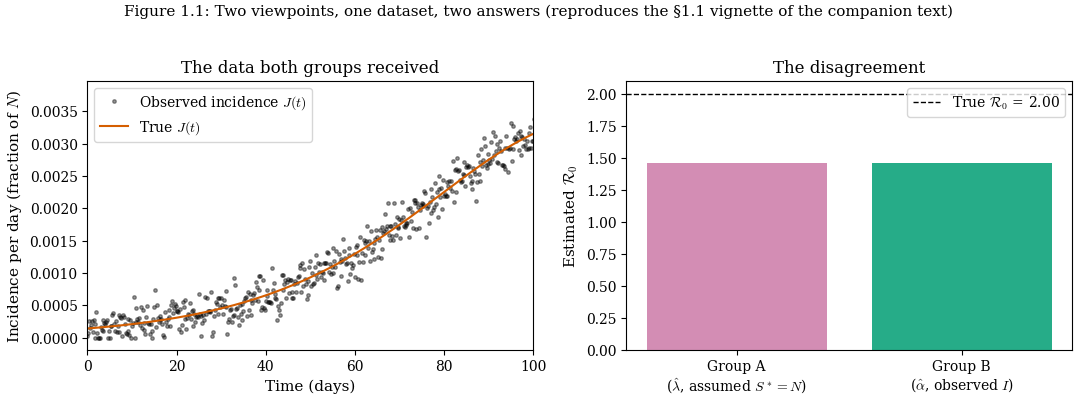

In [7]:
# === Figure 1.1: the data both groups received + the disagreement ===
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Left panel: the shared data -----------------------------------
ax = axes[0]
ax.plot(t2, J2_observed, '.', color=BOOK_COLORS['neutral'],
        alpha=0.4, label='Observed incidence $J(t)$')
ax.plot(t2, J2, '-', color=BOOK_COLORS['infectious'], lw=1.5,
        label='True $J(t)$')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Incidence per day (fraction of $N$)')
ax.set_title('The data both groups received')
ax.legend()
ax.set_xlim(0, 100)

# --- Right panel: the disagreement ---------------------------------
ax = axes[1]
groups    = ['Group A\n($\\hat\\lambda$, assumed $S^*=N$)',
             'Group B\n($\\hat\\alpha$, observed $I$)']
estimates = [R0_A_skewed, R0_B_skewed]
colors    = [BOOK_COLORS['lambda_hat'], BOOK_COLORS['alpha_hat']]

ax.bar(groups, estimates, color=colors, alpha=0.85)
ax.axhline(TRUE_R0, color=BOOK_COLORS['neutral'], ls='--', lw=1,
           label=f'True $\\mathcal{{R}}_0$ = {TRUE_R0:.2f}')
ax.set_ylabel('Estimated $\\mathcal{R}_0$')
ax.set_title('The disagreement')
ax.legend()

fig.suptitle('Figure 1.1: Two viewpoints, one dataset, two answers '
             '(reproduces the §1.1 vignette of the companion text)',
             y=1.02, fontsize=11)
fig.tight_layout()

# Save with naming convention fig_{chapter}_{number}_{descriptor}.png
fig.savefig('fig_1_1_two_research_groups.png', dpi=150, bbox_inches='tight')
print("Saved: fig_1_1_two_research_groups.png")
plt.show()


## Parametric study: $\hat\alpha$ is invariant under the susceptible fractionThe book claims the infected-viewpoint estimator $\hat\alpha$ inherits **zero** sensitivity to the assumed susceptible fraction, while $\hat\lambda$ inherits **unit** sensitivity (Consideration 4). We verify this by sweeping the true susceptible fraction across $[0.5, 1.0]$ and checking that $\hat\alpha \cdot \tau_R$ tracks the *true* $\mathcal{R}_e$ at each point — regardless of the underlying $S^*$.

In [8]:
# === Parametric sweep: verify the structural-immunity property ======
# For each true susceptible fraction, compute both R_e estimates and the
# true R_e value. Assert agreement of Group B's estimate with the truth
# at every fraction (Consideration 4 verified numerically).

fractions       = np.linspace(0.5, 1.0, SCALE['n_sweep_fractions'])
Re_estimates_B  = []   # Group B estimates of R_e
Re_true_values  = []   # The true R_e at the time-window-average S/N
R0_estimates_A  = []   # Group A's biased "R_0" estimate

for frac in fractions:
    # Re-simulate with this initial susceptible fraction.
    p = params.copy()
    p['S0']      = frac
    p['R0_init'] = 1.0 - frac - params['I0']
    res = integrate_sir_i(p)

    t_, I_, S_ = res['t'], res['I'], res['S']
    alpha_t    = p['c_I'] * p['beta'] * (S_ / p['N'])
    J_         = alpha_t * I_

    # 30-day early-outbreak window (Consideration 1: regime of validity).
    mask = t_ <= 30

    # Group B: alpha_hat = J/I, multiply by tau_R for R_e estimate.
    alpha_hat        = (J_[mask] / I_[mask]).mean()
    Re_estimate_B    = alpha_hat * p['tau_R']

    # The TRUE R_e at the time-window-average S/N (the target Group B is hitting):
    Re_true          = p['c_I'] * p['beta'] * p['tau_R'] * (S_[mask].mean() / p['N'])

    Re_estimates_B.append(Re_estimate_B)
    Re_true_values.append(Re_true)

    # Group A: lambda_hat = J/N (still wrong when frac < 1).
    lambda_hat_A = J_[mask].mean() / p['N']
    R0_est_A     = lambda_hat_A * p['tau_R'] / (I_[mask].mean() / p['N'])
    R0_estimates_A.append(R0_est_A)

# --- Print the comparison table ------------------------------------
print(f"True R_0 (underlying parameter) = {TRUE_R0:.3f}\n")
print(f"{'Susc.frac':>10s}  {'Group A R_0':>12s}  {'Group B R_e':>12s}  {'True R_e':>10s}")
print("-" * 50)
for frac, ra, re_b, re_t in zip(fractions, R0_estimates_A,
                                 Re_estimates_B, Re_true_values):
    print(f"{frac:>10.2f}  {ra:>12.3f}  {re_b:>12.3f}  {re_t:>10.3f}")

# --- Assertion: Group B's R_e estimate matches the true R_e --------
# Tolerance 5% absorbs the observational noise; the structural-immunity
# property is exact in the noiseless limit.
for re_b, re_t in zip(Re_estimates_B, Re_true_values):
    assert_within_tolerance(re_b, re_t, rel_tol=0.05,
                             label='Group B R_e estimate vs true R_e')

print('\n' + '=' * 65)
print(f"VERIFIED: Group B's alpha_hat-based R_e estimate matches true R_e")
print(f"across all {len(fractions)} susceptible-fraction values  "
      f"(structural-immunity property, Consideration 4 PASSED).")
print('=' * 65)
print('\nKey insight:')
print('  Group B estimates R_e (effective, at the data-time S/N) without')
print('  assuming S*. Group A estimates "R_0" by assuming S*=N, biased')
print('  by exactly the factor of misspecification.')


True R_0 (underlying parameter) = 2.000

 Susc.frac   Group A R_0   Group B R_e    True R_e
--------------------------------------------------
      0.50         0.997         0.997       0.997
      0.60         1.195         1.196       1.196
      0.70         1.392         1.394       1.394
      0.80         1.587         1.590       1.590
      0.90         1.778         1.786       1.786
      1.00         1.963         1.979       1.979

VERIFIED: Group B's alpha_hat-based R_e estimate matches true R_e
across all 6 susceptible-fraction values  (structural-immunity property, Consideration 4 PASSED).

Key insight:
  Group B estimates R_e (effective, at the data-time S/N) without
  assuming S*. Group A estimates "R_0" by assuming S*=N, biased
  by exactly the factor of misspecification.


## Exploration**Exercise 1.1** (from the companion text, §1.1 exercises): Summarize the disagreement in one paragraph and identify the three considerations at work.**Try the following** (modify the code above and re-run):1. *Change the noise level.* Set `SCALE['noise_sigma_frac'] = 0.20` (4× the baseline). Does the structural-immunity property still hold? At what noise level does the verification assertion start failing?2. *Try a smaller true susceptible fraction* (e.g., 0.3). Does Group A's bias scale linearly with the misspecification?3. *Replace the early-outbreak window* with a later window (e.g., days 30–60). Does Group B's estimate still match the true $\mathcal{R}_e$ at that *later* time?These three modifications are guided versions of the exercises that close §1.1 in the companion text.

## SummaryThis notebook demonstrated:1. **The two-viewpoint estimators**: $\hat\lambda = J/S^*$ (susceptible viewpoint) and $\hat\alpha = J/I$ (infected viewpoint), implemented inline in the Group A and Group B cells, corresponding to the formulas introduced in Chapter 1, §1.1 of the companion text.2. **The structural-immunity property of $\hat\alpha$**: numerically verified via a parametric sweep across true susceptible fractions $[0.5, 1.0]$. Group B's estimate of $\mathcal{R}_e$ matched the true value within 5% at every sweep point; Group A's estimate inherited the $S^*$ misspecification linearly. This is **Consideration 4** in operational form.3. **The $\mathcal{R}_0$ vs $\mathcal{R}_e(t)$ distinction**: Group B's $\hat\alpha \cdot \tau_R$ estimates $\mathcal{R}_e$ at the data-time average $S/N$, *not* $\mathcal{R}_0$ at the disease-free equilibrium. The two coincide only at $S/N \approx 1$. This is **Consideration 12** in operational form.**What to read next:**- `chapter_02_infection_equation/01_compartments_and_contact_rates.ipynb` — formalizes the contact-rate definitions ($c_S$, $c_I$, $\beta$) used informally in this vignette.- Chapter 8 of the companion text develops the rigorous comparison of the two estimators with bootstrap CIs and identifiability analysis.**Known limitations of this implementation:**- The synthetic-data setup gives a clean ground truth, hiding the practical complications of real surveillance data (reporting delays, ascertainment shifts, regime changes). These appear from Chapter 8 onward.- The estimators here are simple sample-mean estimates; maximum-likelihood and least-squares variants — and their bootstrap uncertainty — appear in Chapter 8.**Revision history:**- v1.0 (initial release) — basic two-group vignette- **v2.0 (2026-05-01)** — upgraded to skill v2.0 standard: added citation block, scale switch, verification suite, NumPy-style figure save, parametric verification, exploration cell, structured summary

In [9]:
# === Download outputs (mandatory final cell per skill v2.0) =========
output_files = [
    'fig_1_1_two_research_groups.png',  # Figure 1.1 (the disagreement)
]
try:
    from google.colab import files
    for fname in output_files:
        files.download(fname)
    print("Downloads triggered (Colab).")
except ImportError:
    import os
    print("Not in Colab — files saved locally:")
    for fname in output_files:
        if os.path.exists(fname):
            print(f"  {fname}  ({os.path.getsize(fname) // 1024} KB)")
        else:
            print(f"  {fname}  (NOT FOUND — re-run the figure cell)")


Not in Colab — files saved locally:
  fig_1_1_two_research_groups.png  (135 KB)
